<a href="https://colab.research.google.com/github/abdullahfayed6/Hands-On/blob/main/TransferLearningXception.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [ ]:
import tensorflow_datasets as tfds

dataset, info = tfds.load("tf_flowers", as_supervised=True, with_info=True)
dataset_size = info.splits["train"].num_examples
class_names = info.features["label"].names
n_classes = info.features["label"].num_classes

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/tf_flowers/incomplete.UMNGKR_3.0.1/tf_flowers-train.tfrecord*...:   0%|   …

Dataset tf_flowers downloaded and prepared to /root/tensorflow_datasets/tf_flowers/3.0.1. Subsequent calls will reuse this data.


In [ ]:
dataset_size , class_names , n_classes

(3670, ['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses'], 5)

In [ ]:
test_set_raw, valid_set_raw, train_set_raw = tfds.load(
    "tf_flowers",
    split=["train[:10%]", "train[10%:25%]", "train[25%:]"],
    as_supervised=True)

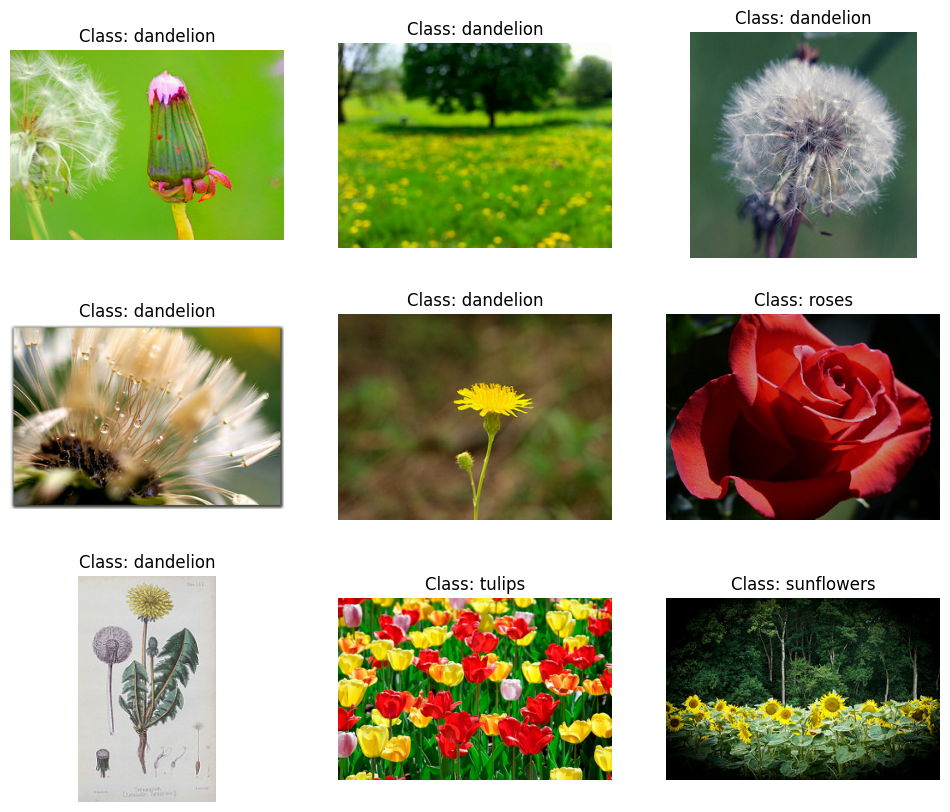

In [ ]:
plt.figure(figsize=(12, 10))
index = 0
for image, label in valid_set_raw.take(9):
    index += 1
    plt.subplot(3, 3, index)
    plt.imshow(image)
    plt.title(f"Class: {class_names[label]}")
    plt.axis("off")

plt.show()

In [ ]:
batch_size = 32
preprocess = tf.keras.Sequential([
    tf.keras.layers.Resizing(height=224, width=224, crop_to_aspect_ratio=True),
    tf.keras.layers.Lambda(tf.keras.applications.xception.preprocess_input)
])
train_set = train_set_raw.map(lambda X, y: (preprocess(X), y))
train_set = train_set.shuffle(1000, seed=42).batch(batch_size).prefetch(1)
valid_set = valid_set_raw.map(lambda X, y: (preprocess(X), y)).batch(batch_size)
test_set = test_set_raw.map(lambda X, y: (preprocess(X), y)).batch(batch_size)

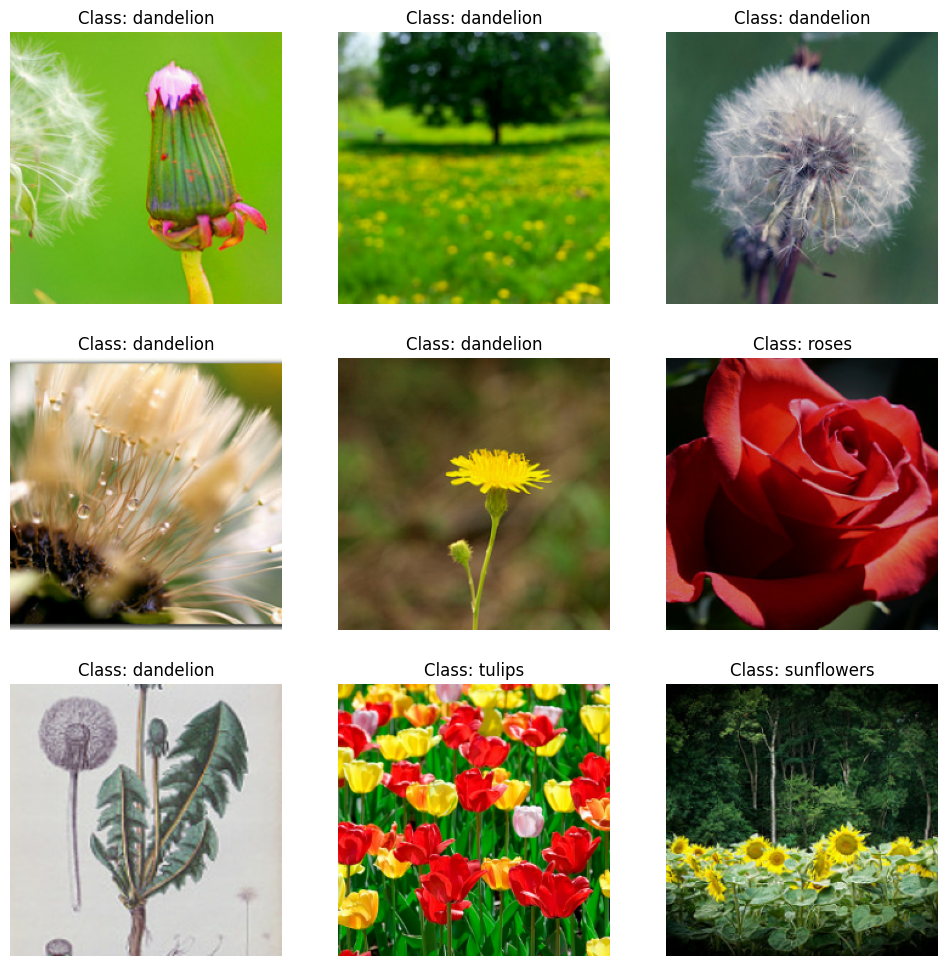

In [ ]:
plt.figure(figsize=(12, 12))
for X_batch, y_batch in valid_set.take(1):
    for index in range(9):
        plt.subplot(3, 3, index + 1)
        plt.imshow((X_batch[index] + 1) / 2)
        plt.title(f"Class: {class_names[y_batch[index]]}")
        plt.axis("off")

plt.show()

In [ ]:
data_augmentation = Sequential([
    layers.RandomFlip(mode="horizontal"),
    layers.RandomRotation(factor=0.05),
    layers.RandomContrast(factor=0.2)
])

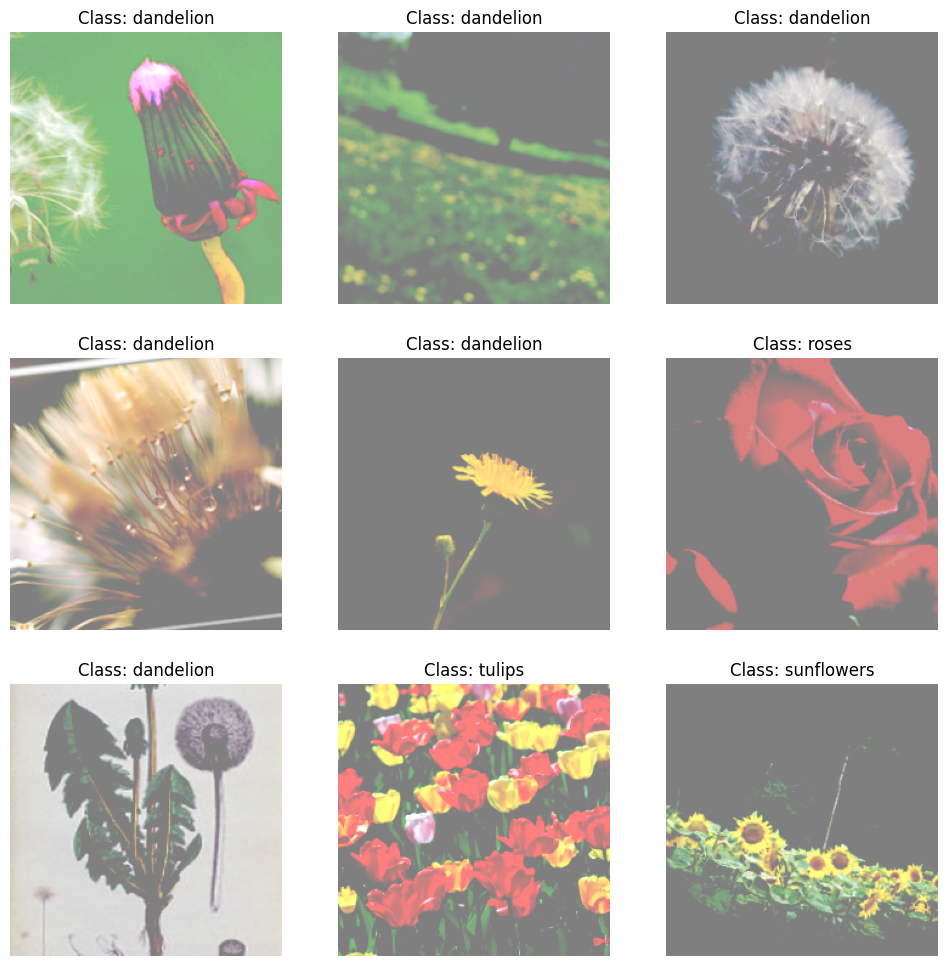

In [ ]:
plt.figure(figsize=(12, 12))
for X_batch, y_batch in valid_set.take(1):
    X_batch_augmented = data_augmentation(X_batch, training=True)
    for index in range(9):
        plt.subplot(3, 3, index + 1)
        plt.imshow(np.clip((X_batch_augmented[index] + 1) / 2, 0, 1))
        plt.title(f"Class: {class_names[y_batch[index]]}")
        plt.axis("off")

plt.show()

In [ ]:
base_model = tf.keras.applications.xception.Xception(weights="imagenet",
                                                     include_top=False)

avg = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
output = tf.keras.layers.Dense(n_classes, activation="softmax")(avg)
model = tf.keras.Model(inputs=base_model.input, outputs=output)

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [ ]:
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.1, momentum=0.9)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])

history = model.fit(train_set, validation_data=valid_set, epochs=3)

Epoch 1/3
86/86 ━━━━━━━━━━━━━━━━━━━━ 57s 364ms/step - accuracy: 0.7060 - loss: 1.0234 - val_accuracy: 0.8385 - val_loss: 0.6247
Epoch 2/3
86/86 ━━━━━━━━━━━━━━━━━━━━ 16s 175ms/step - accuracy: 0.9161 - loss: 0.3017 - val_accuracy: 0.8657 - val_loss: 0.5867
Epoch 3/3
86/86 ━━━━━━━━━━━━━━━━━━━━ 16s 185ms/step - accuracy: 0.9310 - loss: 0.2212 - val_accuracy: 0.8621 - val_loss: 0.5677


In [ ]:
for layer in base_model.layers[56:]:
    layer.trainable = True

optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])
history = model.fit(train_set, validation_data=valid_set, epochs=10)

Epoch 1/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 62s 473ms/step - accuracy: 0.8719 - loss: 0.3784 - val_accuracy: 0.8730 - val_loss: 0.6222
Epoch 2/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 32s 364ms/step - accuracy: 0.9800 - loss: 0.0606 - val_accuracy: 0.9165 - val_loss: 0.2874
Epoch 3/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 32s 367ms/step - accuracy: 0.9978 - loss: 0.0116 - val_accuracy: 0.9183 - val_loss: 0.2831
Epoch 4/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 32s 364ms/step - accuracy: 0.9967 - loss: 0.0085 - val_accuracy: 0.9111 - val_loss: 0.2999
Epoch 5/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 32s 367ms/step - accuracy: 0.9987 - loss: 0.0036 - val_accuracy: 0.9056 - val_loss: 0.3105
Epoch 6/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 32s 364ms/step - accuracy: 0.9991 - loss: 0.0041 - val_accuracy: 0.9129 - val_loss: 0.2979
Epoch 7/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 32s 365ms/step - accuracy: 0.9976 - loss: 0.0076 - val_accuracy: 0.9129 - val_loss: 0.2977
Epoch 8/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 32s 366ms/step - accuracy: 0.9999 - loss: 0.0017 - val_accu

In [ ]:
model.evaluate(test_set)

12/12 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.9177 - loss: 0.2428


[0.21588490903377533, 0.9291552901268005]

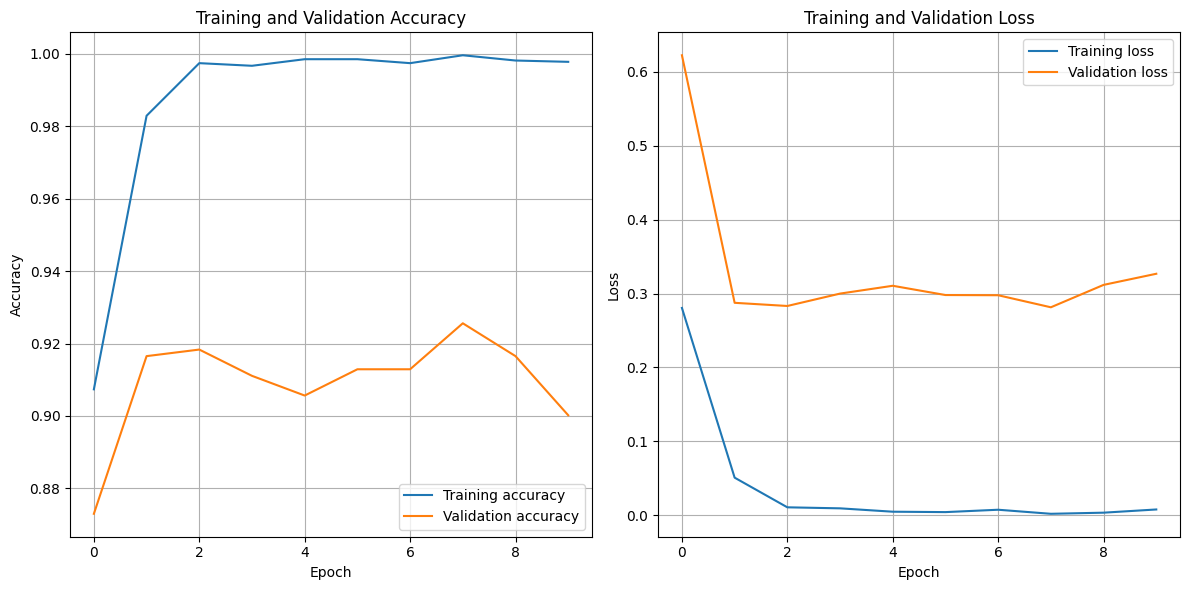

In [ ]:
hist = history.history
acc = hist['accuracy']
val_acc = hist['val_accuracy']
loss = hist['loss']
val_loss = hist['val_loss']
epochs = range(len(acc))

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, label='Training accuracy')
plt.plot(epochs, val_acc, label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, loss, label='Training loss')
plt.plot(epochs, val_loss, label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()